In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("C:/Users/yhy_s/Desktop/DSC106/project-2/persuasive_deceptive_climate_change/data/lancaster-contacts-data-store-2021-10-15.csv")

In [4]:
list(df.columns)

['CONTACT_ID',
 'PATROL_STATION',
 'DATE_TIME',
 'NUMBER_OF_MINUTES',
 'STREET_NUMBER',
 'DIRECTION',
 'STREET',
 'TYPE',
 'SUITE',
 'CROSS_STREET',
 'LANDMARK',
 'FULL_STREET',
 'CITY',
 'STATE',
 'ZIP_CODE',
 'K_12_SCHOOL',
 'SCHOOL_NAME',
 'CALL_FOR_SERVICE',
 'CIVILIANS_CONTACTED',
 'Person ID',
 'Street #',
 'Street Direction',
 'Street Name',
 'Street Type',
 'Suite',
 'Cross Street',
 'Landmark',
 'Full Address',
 'City',
 'State',
 'Zip Code',
 'Age?',
 'K12 Student?',
 'Limited or No English Fluency?',
 'Perception Made',
 'Homeless?',
 'Gender',
 'Race',
 'Disability',
 'Reason for Contact',
 'Reason for Contact Narrative',
 'Traffic Violation Type',
 'Traffic Violation Offense Code',
 'Reasonable Suspicion that the Officer Witnessed Commission of a Crime?',
 'Reasonable Suspicion that the Person Matched Suspect Description?',
 'Reasonable Suspicion that the Person was a Witness or Victim ID of Suspect at the Scene?',
 'Reasonable Suspicion that the Person may be Carrying Sus

#### Check missingness of each columns

In [10]:
missing_df = (
    df.isna()
    .mean()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_rate'})
    .sort_values(by='missing_rate', ascending=False)
)

pd.set_option('display.max_rows', None)
missing_df

,column,missing_rate
42,Traffic Violation Offense Code,1.000000
54,Education Code Subdivision,1.000000
53,Education Code Section,1.000000
41,Traffic Violation Type,1.000000
76,Asked Consent to Search Property Given?,0.984691
10,LANDMARK,0.976388
26,Landmark,0.976388
8,SUITE,0.959782
24,Suite,0.959782
127,Result of Contact:Citation for Infraction Offe...,0.957966


#### Distribution and count of `Race` column

In [13]:
df['Race'].value_counts(dropna=False)

Race
Black/African American                                                                                                         1926
Hispanic/Latino/Latina                                                                                                          988
White                                                                                                                           757
Hispanic/Latino/Latina, White                                                                                                    58
Asian, Black/African American, Hispanic/Latino/Latina, Middle Eastern/South Asian, Native American, Pacific Islander, White      27
Black/African American, Hispanic/Latino/Latina                                                                                   23
Middle Eastern/South Asian                                                                                                       21
Asian                                                                  

In [14]:
df['Race'].nunique()

25

In [15]:
df['Race'].value_counts(normalize=True)

Race
Black/African American                                                                                                         0.499741
Hispanic/Latino/Latina                                                                                                         0.256357
White                                                                                                                          0.196419
Hispanic/Latino/Latina, White                                                                                                  0.015049
Asian, Black/African American, Hispanic/Latino/Latina, Middle Eastern/South Asian, Native American, Pacific Islander, White    0.007006
Black/African American, Hispanic/Latino/Latina                                                                                 0.005968
Middle Eastern/South Asian                                                                                                     0.005449
Asian                                      

In [20]:
single_df = df.copy()

single_df = df[~df['Race'].str.contains(',')]

major = [
    'Black/African American',
    'Hispanic/Latino/Latina',
    'White',
    'Asian'
]

single_df['race_group'] = single_df['Race'].apply(
    lambda x: x if x in major else 'Other'
)

single_df['race_group'].value_counts(normalize=True)

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_12764\1616576472.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_df['race_group'] = single_df['Race'].apply(


race_group
Black/African American    0.517881
Hispanic/Latino/Latina    0.265663
White                     0.203549
Other                     0.008604
Asian                     0.004302
Name: proportion, dtype: float64

#### Combine Asian into "Other" due to very small sample sizes.

In [22]:
single_df['race_group'] = single_df['Race'].apply(
    lambda x: x if x in [
        'Black/African American',
        'Hispanic/Latino/Latina',
        'White'
    ] else 'Other'
)

single_df['race_group'].value_counts(normalize=True)

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_12764\3333691798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  single_df['race_group'] = single_df['Race'].apply(


race_group
Black/African American    0.517881
Hispanic/Latino/Latina    0.265663
White                     0.203549
Other                     0.012907
Name: proportion, dtype: float64

In [23]:
import pandas as pd
import numpy as np

# 1. remove multi-racial records
single_df = df[~df['Race'].str.contains(',', na=False)].copy()

# 2. create race_group
major = [
    'Black/African American',
    'Hispanic/Latino/Latina',
    'White'
]

single_df['race_group'] = single_df['Race'].apply(
    lambda x: x if x in major else 'Other'
)

# 3. create outcome indicators
single_df['searched'] = single_df['Search of Person Conducted?'] == True

single_df['contraband_found'] = (
    (single_df['Search of Person Conducted?'] == True) &
    (single_df['Contraband Evidence Discovered: None?'] == False)
)

single_df['low_level_outcome'] = (
    (single_df['Result of Contact: No Action?'] == True) |
    (single_df['Result of Contact: Warning?'] == True)
)

# 4. summary table
summary = (
    single_df
    .groupby('race_group')
    .agg(
        total_contacts=('CONTACT_ID', 'count'),
        searches=('searched', 'sum'),
        contraband_found=('contraband_found', 'sum'),
        no_action_or_warning=('low_level_outcome', 'sum')
    )
)

summary['search_rate'] = summary['searches'] / summary['total_contacts']
summary['contraband_success_rate'] = summary['contraband_found'] / summary['searches']
summary['low_level_outcome_rate'] = summary['no_action_or_warning'] / summary['total_contacts']

summary.sort_values('total_contacts', ascending=False)

,total_contacts,searches,contraband_found,no_action_or_warning,search_rate,contraband_success_rate,low_level_outcome_rate
race_group,,,,,,,
Black/African American,1926,864,190,501,0.448598,0.219907,0.260125
Hispanic/Latino/Latina,988,488,147,219,0.493927,0.301230,0.221660
White,757,346,99,194,0.457067,0.286127,0.256275
Other,48,23,3,7,0.479167,0.130435,0.145833


In [39]:
import matplotlib.pyplot as plt

# 1. remove multi-racial records
single_df = df[~df['Race'].str.contains(',', na=False)].copy()

# 2. create 3 race groups
def map_race_3(x):
    if x == 'Black/African American':
        return 'African American'
    elif x == 'White':
        return 'White'
    else:
        return 'Other'

single_df['race_group_3'] = single_df['Race'].apply(map_race_3)

# 3. indicators
single_df['searched'] = single_df['Search of Person Conducted?'] == True

single_df['contraband_found'] = (
    (single_df['Search of Person Conducted?'] == True) &
    (single_df['Contraband Evidence Discovered: None?'] == False)
)

# 4. summary
summary_3 = (
    single_df
    .groupby('race_group_3')
    .agg(
        total_contacts=('CONTACT_ID', 'count'),
        searches=('searched', 'sum'),
        contraband_found=('contraband_found', 'sum')
    )
)

summary_3['contraband_success_rate'] = (
    summary_3['contraband_found'] / summary_3['searches']
)

summary_3

,total_contacts,searches,contraband_found,contraband_success_rate
race_group_3,,,,
African American,1926,864,190,0.219907
Other,1036,511,150,0.293542
White,757,346,99,0.286127


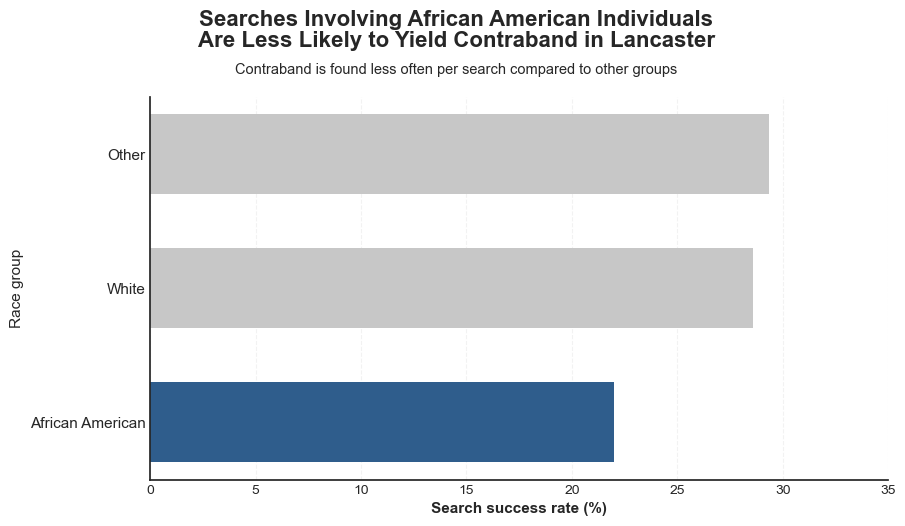

In [66]:
plt.style.use('seaborn-v0_8-white')

order = ['African American', 'White', 'Other']

plot_df = summary_3.loc[order].copy()
plot_df['pct'] = plot_df['contraband_success_rate'] * 100

colors = [
    '#2F5D8C' if group == 'African American' else '#c7c7c7'
    for group in plot_df.index
]

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.barh(plot_df.index, plot_df['pct'], color=colors, height=0.6)

# title + subtitle
fig.suptitle(
    'Searches Involving African American Individuals\nAre Less Likely to Yield Contraband in Lancaster',
    fontsize=16,
    fontweight='bold',
    y=0.93,
    ha='center',
    linespacing=1.05
)

fig.text(
    0.5, 0.82,
    'Contraband is found less often per search compared to other groups',
    ha='center',
    fontsize=10.5
)

ax.set_xlabel('Search success rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Race group', fontsize=11)

ax.set_xlim(0, 35)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.grid(True, linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

# leave space for title/subtitle
plt.subplots_adjust(top=0.78, left=0.16, right=0.98, bottom=0.12)

plt.show()

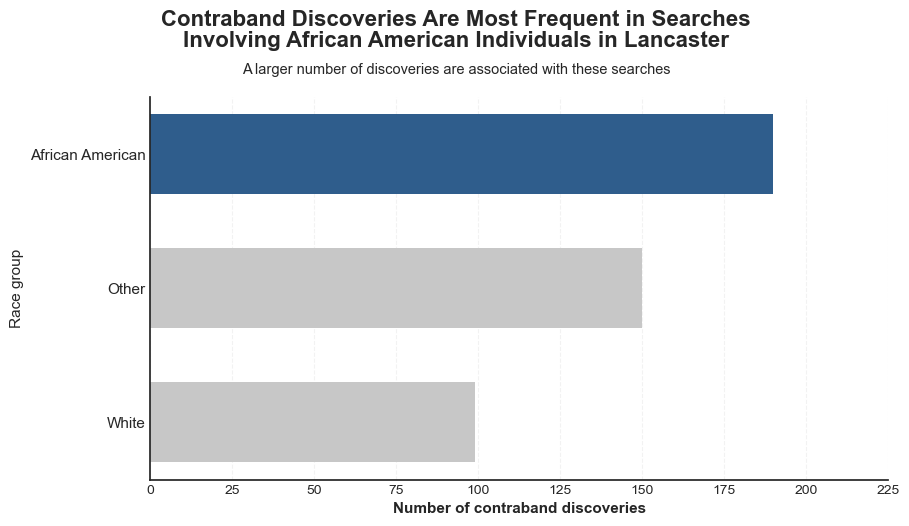

In [67]:
plt.style.use('seaborn-v0_8-white')

plot_df = summary_3.copy()
plot_df = plot_df.sort_values('contraband_found', ascending=True)

# Highlight African American, gray out others
colors = [
    '#2F5D8C' if group == 'African American' else '#c7c7c7'
    for group in plot_df.index
]

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.barh(plot_df.index, plot_df['contraband_found'], color=colors, height=0.6)

fig.suptitle(
    'Contraband Discoveries Are Most Frequent in Searches\nInvolving African American Individuals in Lancaster',
    fontsize=16,
    fontweight='bold',
    y=0.93,
    ha='center',
    linespacing=1.05
)

fig.text(
    0.5, 0.82,
    'A larger number of discoveries are associated with these searches',
    ha='center',
    fontsize=10.5
)

ax.set_xlabel('Number of contraband discoveries', fontsize=11, fontweight='bold')
ax.set_ylabel('Race group', fontsize=11)

ax.set_xlim(0, max(plot_df['contraband_found']) + 35)

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.grid(True, linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

plt.subplots_adjust(top=0.78, left=0.16, right=0.98, bottom=0.12)

plt.show()

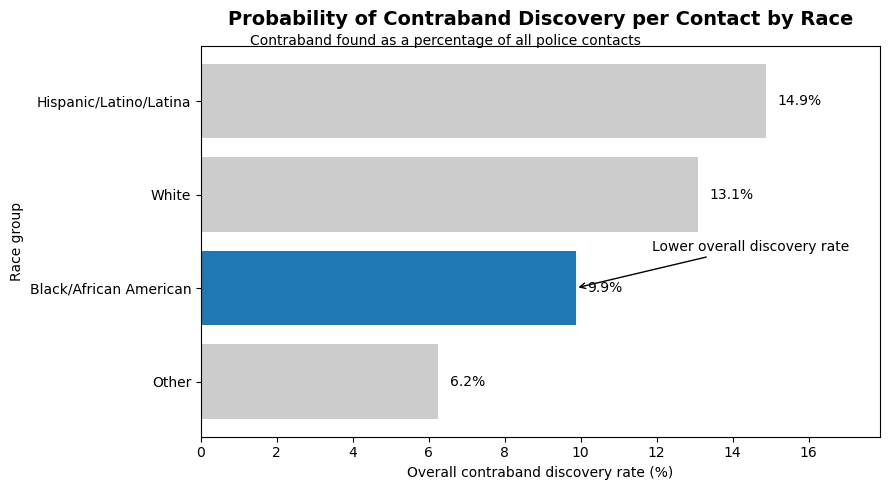

In [ ]:
import matplotlib.pyplot as plt

plot_df = summary.copy()

plot_df['overall_hit_rate'] = (
    plot_df['contraband_found'] / plot_df['total_contacts'] * 100
)

plot_df = plot_df.sort_values('overall_hit_rate')

colors = ['#cccccc' if group != 'Black/African American' else '#1f77b4'
          for group in plot_df.index]

plt.figure(figsize=(9,5))

plt.barh(plot_df.index, plot_df['overall_hit_rate'], color=colors)

plt.title(
    'Probability of Contraband Discovery per Contact by Race',
    fontsize=14,
    weight='bold',
    pad=15
)

plt.figtext(
    0.5, 0.90,
    'Contraband found as a percentage of all police contacts',
    ha='center',
    fontsize=10
)

plt.xlabel('Overall contraband discovery rate (%)')
plt.ylabel('Race group')

for i, (group, row) in enumerate(plot_df.iterrows()):
    plt.text(
        row['overall_hit_rate'] + 0.3,
        i,
        f"{row['overall_hit_rate']:.1f}%",
        va='center',
        fontsize=10
    )

# annotation
black_rate = plot_df.loc['Black/African American', 'overall_hit_rate']
black_idx = list(plot_df.index).index('Black/African American')

plt.annotate(
    'Lower overall discovery rate',
    xy=(black_rate, black_idx),
    xytext=(black_rate + 2, black_idx + 0.4),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

plt.xlim(0, max(plot_df['overall_hit_rate']) + 3)

plt.tight_layout()
plt.show()